# **1. Perkenalan Dataset**


## **INFORMASI DATASET**

Dataset ini menyajikan gambaran mendalam mengenai perilaku transaksi dan pola aktivitas keuangan, sehingga sangat ideal untuk eksplorasi **deteksi penipuan (fraud detection)** dan **identifikasi anomali**. Dataset ini mencakup **2.512 sampel data transaksi**, yang mencakup berbagai atribut transaksi, demografi nasabah, dan pola penggunaan.

Setiap entri memberikan wawasan komprehensif terhadap perilaku transaksi, memungkinkan analisis untuk **keamanan finansial** dan pengembangan model prediktif.

## Fitur Utama

- **`TransactionID`**: Pengidentifikasi unik alfanumerik untuk setiap transaksi.  
- **`AccountID`**: ID unik untuk setiap akun, dapat memiliki banyak transaksi.  
- **`TransactionAmount`**: Nilai transaksi dalam mata uang, mulai dari pengeluaran kecil hingga pembelian besar.  
- **`TransactionDate`**: Tanggal dan waktu transaksi terjadi.  
- **`TransactionType`**: Tipe transaksi berupa `'Credit'` atau `'Debit'`.  
- **`Location`**: Lokasi geografis transaksi (nama kota di Amerika Serikat).  
- **`DeviceID`**: ID perangkat yang digunakan dalam transaksi.  
- **`IP Address`**: Alamat IPv4 yang digunakan saat transaksi, dapat berubah untuk beberapa akun.  
- **`MerchantID`**: ID unik merchant, menunjukkan merchant utama dan anomali transaksi.  
- **`AccountBalance`**: Saldo akun setelah transaksi berlangsung.  
- **`PreviousTransactionDate`**: Tanggal transaksi terakhir pada akun, berguna untuk menghitung frekuensi transaksi.  
- **`Channel`**: Kanal transaksi seperti `Online`, `ATM`, atau `Branch`.  
- **`CustomerAge`**: Usia pemilik akun.  
- **`CustomerOccupation`**: Profesi pengguna seperti `Dokter`, `Insinyur`, `Mahasiswa`, atau `Pensiunan`.  
- **`TransactionDuration`**: Lama waktu transaksi (dalam detik).  
- **`LoginAttempts`**: Jumlah upaya login sebelum transaksi—jumlah tinggi bisa mengindikasikan anomali.

Tugas kamu adalah membuat model clustering yang selanjutnya akan digunakan untuk membuat model klasifikasi.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning.

In [1]:
#Type your code here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# **3. Data Wrangling**

## Read data

In [2]:
# Upload data
from google.colab import files
uploaded = files.upload()

Saving hasil_clustering_kmeans.csv to hasil_clustering_kmeans.csv


In [3]:
# Baca data

df = pd.read_csv('hasil_clustering_kmeans.csv')
df.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,cluster
0,TX000036,AC00267,124.76,2023-10-16 16:32:56,debit,seattle,D000042,59.145.242.13,M002,branch,49.0,engineer,45.0,1.0,5764.72,2024-11-04 08:06:23,4
1,TX000470,AC00036,71.95,2023-02-13 16:39:52,credit,unknown,D000410,162.58.247.55,M100,online,59.0,engineer,53.0,1.0,9267.32,2024-11-04 08:06:23,1
2,TX002045,AC00241,188.61,2024-01-01 17:16:23,debit,boston,D000451,107.248.120.12,M083,online,67.0,retired,26.0,1.0,7167.57,2024-11-04 08:06:23,4
3,TX002108,AC00190,46.60,2023-08-30 17:54:55,debit,detroit,D000029,147.227.81.224,M060,online,55.0,doctor,68.0,1.0,1562.90,2024-11-04 08:06:23,4
4,TX002424,AC00340,332.06,2023-06-21 16:38:54,debit,seattle,D000365,94.37.250.128,M086,atm,29.0,doctor,221.0,1.0,11826.52,2024-11-04 08:06:23,2


## Data asessing

In [7]:
# cek info data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2486 entries, 0 to 2485
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2486 non-null   object 
 1   AccountID                2486 non-null   object 
 2   TransactionAmount        2486 non-null   float64
 3   PreviousTransactionDate  2486 non-null   object 
 4   TransactionType          2486 non-null   object 
 5   Location                 2486 non-null   object 
 6   DeviceID                 2486 non-null   object 
 7   IP Address               2486 non-null   object 
 8   MerchantID               2486 non-null   object 
 9   Channel                  2486 non-null   object 
 10  CustomerAge              2486 non-null   float64
 11  CustomerOccupation       2486 non-null   object 
 12  TransactionDuration      2486 non-null   float64
 13  LoginAttempts            2486 non-null   float64
 14  AccountBalance          

In [8]:
# cek missing value
df.isna().sum()

,0
TransactionID,0
AccountID,0
TransactionAmount,0
PreviousTransactionDate,0
TransactionType,0
Location,0
DeviceID,0
IP Address,0
MerchantID,0
Channel,0


In [9]:
# cek duplicated data
df.duplicated().sum()


np.int64(0)

# **4. Exploratory Data Analisis (EDA)**

In [10]:
# cek deskriptif data
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,cluster
count,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000
mean,296.251879,44.632341,119.393403,1.121883,5111.522868,2.260257
std,288.764636,17.726198,69.554626,0.595107,3876.575174,1.424225
min,0.260000,18.000000,10.000000,1.000000,101.250000,0.000000
25%,83.180000,27.000000,63.000000,1.000000,1519.357500,1.000000
50%,211.695000,45.000000,112.000000,1.000000,4732.810000,3.000000
75%,409.347500,59.000000,161.000000,1.000000,7643.307500,4.000000
max,1831.020000,80.000000,300.000000,5.000000,14977.990000,4.000000


/tmp/ipykernel_10586/1833049149.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


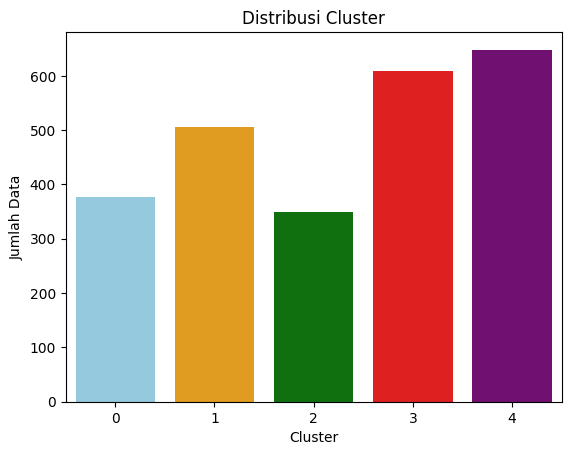

In [38]:
# visualisasi Distribusi kelas Label

# Warna custom
colors = ['skyblue', 'orange', 'green', 'red', 'purple']

# Countplot
sns.countplot(
    x='cluster',
    data=df,
    palette=colors
)

plt.title('Distribusi Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')

plt.show()

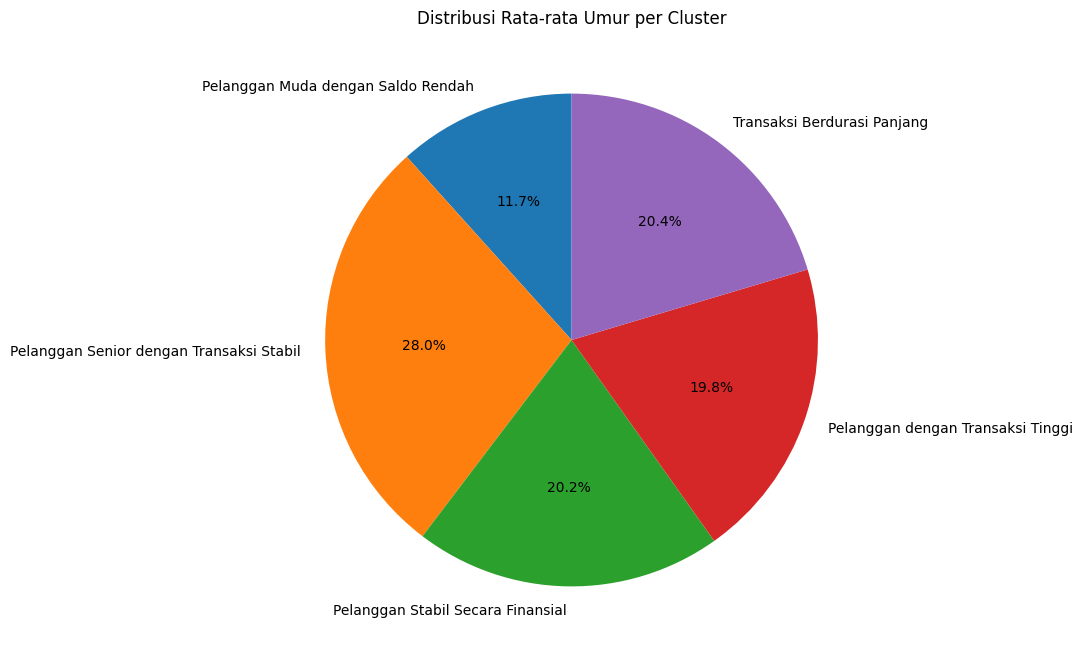

In [37]:
# Nama cluster
cluster_names = {
    0: 'Pelanggan dengan Transaksi Tinggi',
    1: 'Pelanggan Stabil Secara Finansial',
    2: 'Transaksi Berdurasi Panjang',
    3: 'Pelanggan Muda dengan Saldo Rendah',
    4: 'Pelanggan Senior dengan Transaksi Stabil'
}

# Menambahkan nama cluster ke dataframe
df['cluster_name'] = df['cluster'].map(cluster_names)

# Distribusi rata-rata umur per cluster
age_cluster = df.groupby('cluster_name')['CustomerAge'].mean()

# Pie chart
plt.figure(figsize=(8,8))
plt.pie(
    age_cluster,
    labels=age_cluster.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Distribusi Rata-rata Umur per Cluster')
plt.show()

**Insight Utama**

Hasil clustering menunjukkan bahwa perilaku transaksi pelanggan memiliki pola yang beragam. Cluster 0 dan Cluster 2 menjadi kelompok yang paling menarik untuk analisis fraud karena memiliki karakteristik transaksi yang tidak normal, seperti nominal transaksi yang sangat tinggi dan durasi transaksi yang lebih lama dibanding cluster lainnya.

Sementara itu, Cluster 1, Cluster 3, dan Cluster 4 menunjukkan pola transaksi yang relatif stabil dan cenderung memiliki risiko lebih rendah.

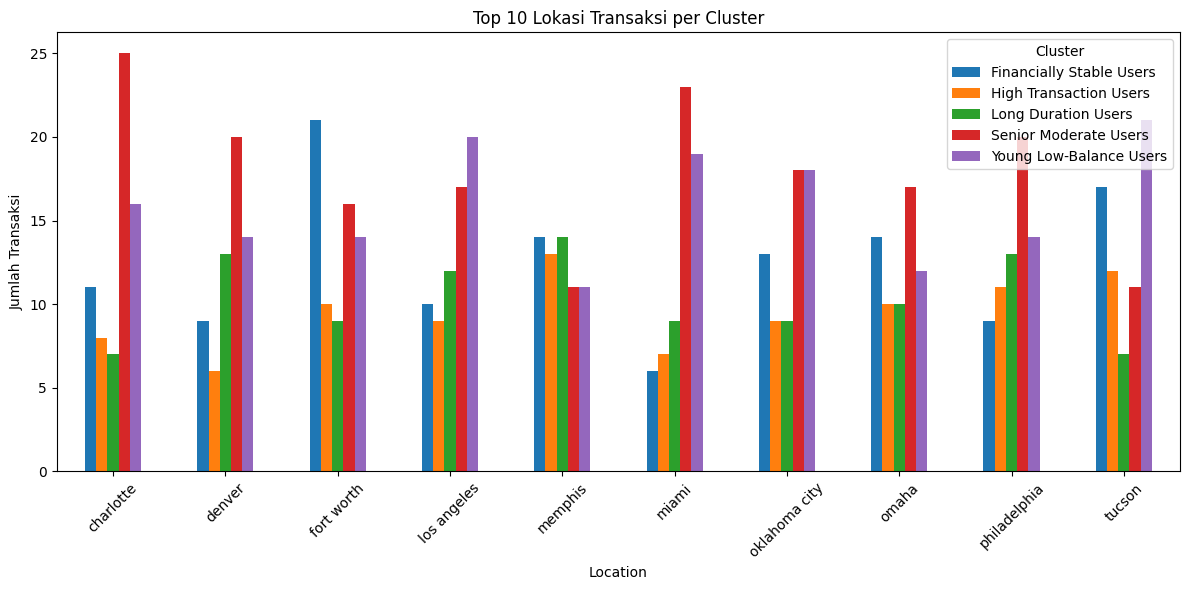

In [13]:
# Lokasi Transaksi
# Ambil top 10 lokasi
top_locations = df['Location'].value_counts().head(10).index

# Filter data
df_top = df[df['Location'].isin(top_locations)]

# Crosstab
location_cluster = pd.crosstab(
    df_top['Location'],
    df_top['cluster_name']
)

# Plot
location_cluster.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Top 10 Lokasi Transaksi per Cluster')
plt.xlabel('Location')
plt.ylabel('Jumlah Transaksi')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.tight_layout()
plt.show()

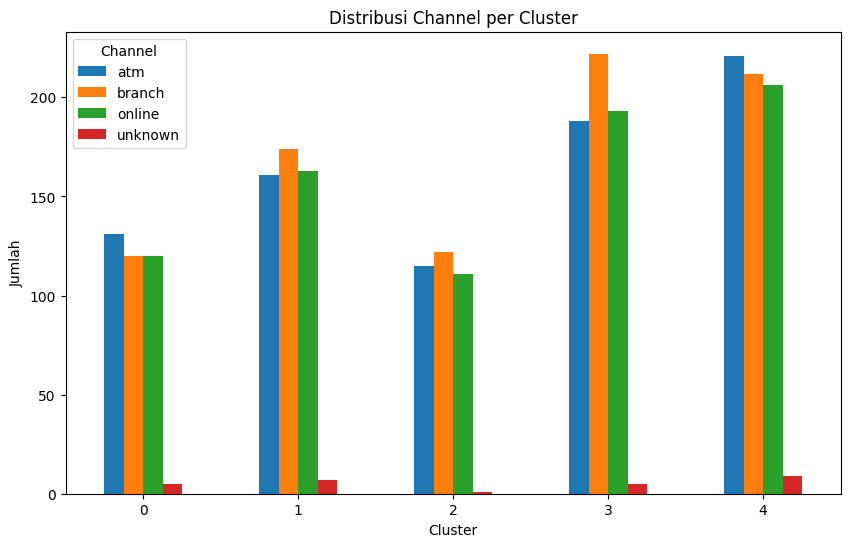

In [14]:
# Distribusi Channel
channel_cluster = pd.crosstab(
    df['cluster'],
    df['Channel']
)

# Bar plot
channel_cluster.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Distribusi Channel per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.show()

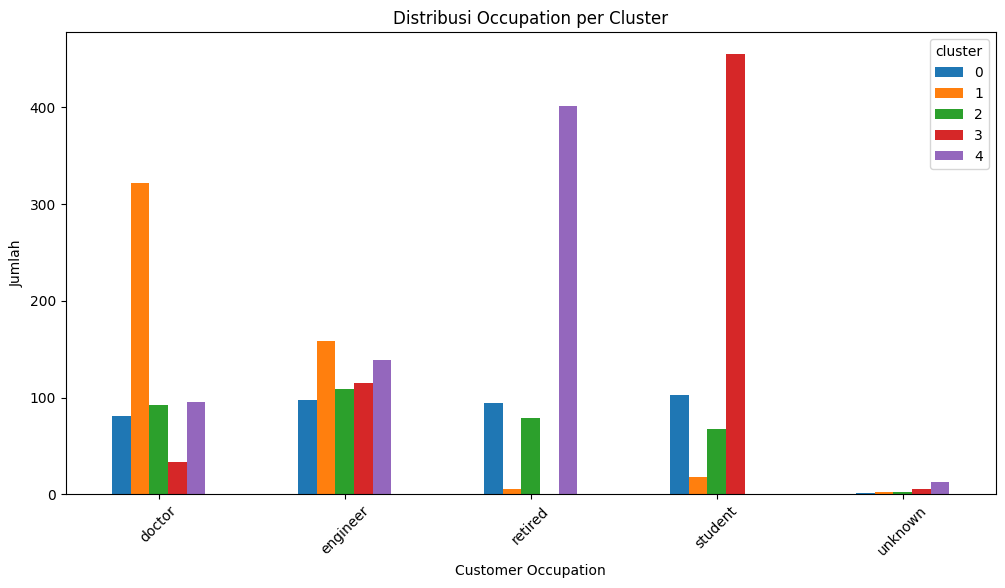

In [15]:
# Occupation per Cluster
occupation_cluster = pd.crosstab(
    df['CustomerOccupation'],
    df['cluster']
)

# Bar plot
occupation_cluster.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Distribusi Occupation per Cluster')
plt.xlabel('Customer Occupation')
plt.ylabel('Jumlah')
plt.xticks(rotation=45)

plt.show()

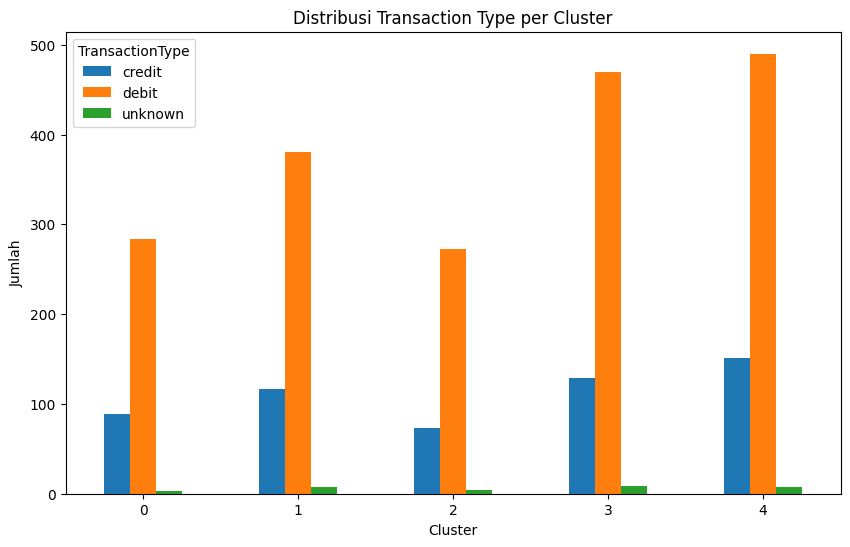

In [16]:
# Distribusi Transaction Type
transaction_type = pd.crosstab(
    df['cluster'],
    df['TransactionType']
)

# Bar plot
transaction_type.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Distribusi Transaction Type per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)

plt.show()

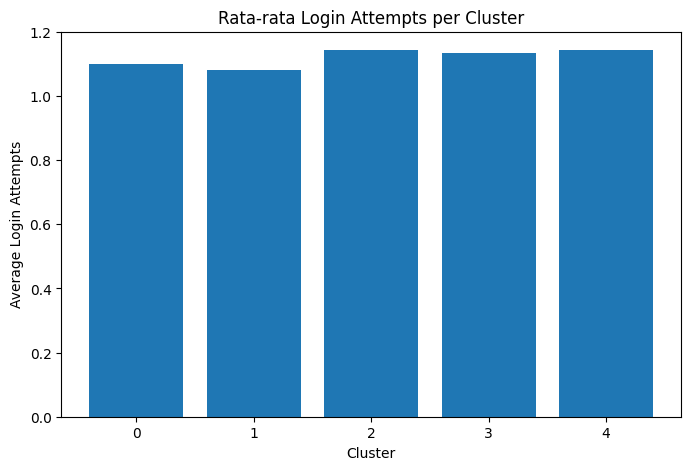

In [17]:
# Rata-rata Login Attempts per Cluster
login_cluster = df.groupby('cluster')['LoginAttempts'].mean().reset_index()

# Bar plot
plt.figure(figsize=(8,5))

plt.bar(
    login_cluster['cluster'],
    login_cluster['LoginAttempts']
)

plt.title('Rata-rata Login Attempts per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average Login Attempts')

plt.show()

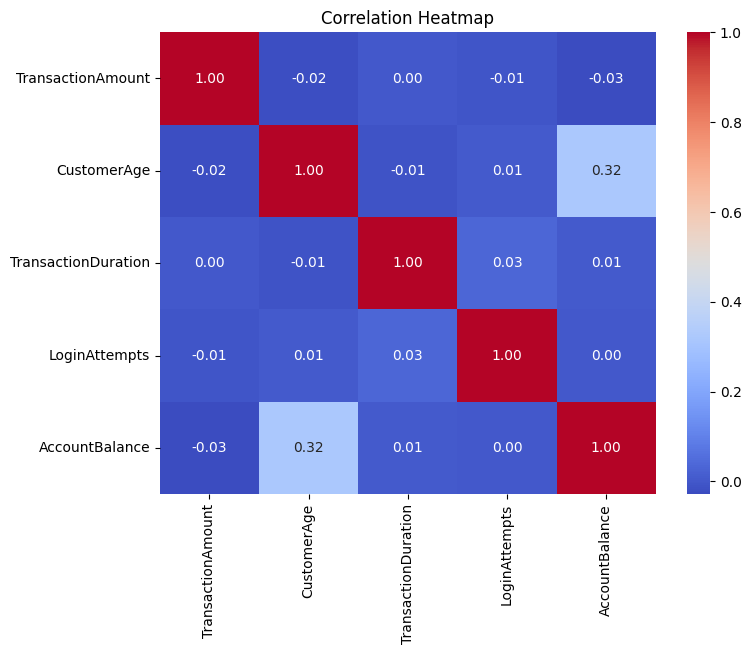

In [18]:
# Korelasi untuk Heatmap
corr = df[
    [
        'TransactionAmount',
        'CustomerAge',
        'TransactionDuration',
        'LoginAttempts',
        'AccountBalance'
    ]
].corr()

# Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

In [19]:
# KPI

total_transaction = len(df)

avg_transaction = df['TransactionAmount'].mean()

avg_balance = df['AccountBalance'].mean()

most_channel = df['Channel'].mode()[0]

# Menampilkan KPI
print(f"Total Transaction     : {total_transaction}")
print(f"Average Transaction   : {avg_transaction:.2f}")
print(f"Average Balance       : {avg_balance:.2f}")
print(f"Most Used Channel     : {most_channel}")

Total Transaction     : 2486
Average Transaction   : 296.25
Average Balance       : 5111.52
Most Used Channel     : branch


# **5. Data Preprocessing**

## Encode data

In [20]:
df_clean = df.copy()

In [21]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2486 entries, 0 to 2485
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2486 non-null   object 
 1   AccountID                2486 non-null   object 
 2   TransactionAmount        2486 non-null   float64
 3   PreviousTransactionDate  2486 non-null   object 
 4   TransactionType          2486 non-null   object 
 5   Location                 2486 non-null   object 
 6   DeviceID                 2486 non-null   object 
 7   IP Address               2486 non-null   object 
 8   MerchantID               2486 non-null   object 
 9   Channel                  2486 non-null   object 
 10  CustomerAge              2486 non-null   float64
 11  CustomerOccupation       2486 non-null   object 
 12  TransactionDuration      2486 non-null   float64
 13  LoginAttempts            2486 non-null   float64
 14  AccountBalance          

In [22]:
df_clean.head()

,TransactionID,AccountID,TransactionAmount,PreviousTransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDate,cluster,cluster_name
0,TX000036,AC00267,124.76,2023-10-16 16:32:56,debit,seattle,D000042,59.145.242.13,M002,branch,49.0,engineer,45.0,1.0,5764.72,2024-11-04 08:06:23,4,Senior Moderate Users
1,TX000470,AC00036,71.95,2023-02-13 16:39:52,credit,unknown,D000410,162.58.247.55,M100,online,59.0,engineer,53.0,1.0,9267.32,2024-11-04 08:06:23,1,Financially Stable Users
2,TX002045,AC00241,188.61,2024-01-01 17:16:23,debit,boston,D000451,107.248.120.12,M083,online,67.0,retired,26.0,1.0,7167.57,2024-11-04 08:06:23,4,Senior Moderate Users
3,TX002108,AC00190,46.60,2023-08-30 17:54:55,debit,detroit,D000029,147.227.81.224,M060,online,55.0,doctor,68.0,1.0,1562.90,2024-11-04 08:06:23,4,Senior Moderate Users
4,TX002424,AC00340,332.06,2023-06-21 16:38:54,debit,seattle,D000365,94.37.250.128,M086,atm,29.0,doctor,221.0,1.0,11826.52,2024-11-04 08:06:23,2,Long Duration Users


In [23]:
# Hapus kolom yang tidak diperlukan

df_encode = df_clean.copy()

df_encode = df_encode.drop(columns=[
    'TransactionID',
    'AccountID',
    'DeviceID',
    'IP Address',
    'MerchantID',
    'cluster_name',
    'Location'
])

df_encode.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2486 entries, 0 to 2485
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionAmount        2486 non-null   float64
 1   PreviousTransactionDate  2486 non-null   object 
 2   TransactionType          2486 non-null   object 
 3   Channel                  2486 non-null   object 
 4   CustomerAge              2486 non-null   float64
 5   CustomerOccupation       2486 non-null   object 
 6   TransactionDuration      2486 non-null   float64
 7   LoginAttempts            2486 non-null   float64
 8   AccountBalance           2486 non-null   float64
 9   TransactionDate          2486 non-null   object 
 10  cluster                  2486 non-null   int64  
dtypes: float64(5), int64(1), object(5)
memory usage: 213.8+ KB


In [24]:
# Konversi kembali ke datetime
# Konversi datetime
df_encode['TransactionDate'] = pd.to_datetime(df_encode['TransactionDate'])
df_encode['PreviousTransactionDate'] = pd.to_datetime(df_encode['PreviousTransactionDate'])

# Ambil fitur numerik
df_encode['Transaction_Hour'] = df_encode['TransactionDate'].dt.hour
df_encode['Transaction_Day'] = df_encode['TransactionDate'].dt.day
df_encode['Transaction_Month'] = df_encode['TransactionDate'].dt.month

df_encode['Previous_Hour'] = df_encode['PreviousTransactionDate'].dt.hour
df_encode['Previous_Day'] = df_encode['PreviousTransactionDate'].dt.day
df_encode['Previous_Month'] = df_encode['PreviousTransactionDate'].dt.month

# Hapus kolom datetime asli
df_encode = df_encode.drop(
    columns=['TransactionDate', 'PreviousTransactionDate']
)

In [25]:
df_encode.head()

,TransactionAmount,TransactionType,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,cluster,Transaction_Hour,Transaction_Day,Transaction_Month,Previous_Hour,Previous_Day,Previous_Month
0,124.76,debit,branch,49.0,engineer,45.0,1.0,5764.72,4,8,4,11,16,16,10
1,71.95,credit,online,59.0,engineer,53.0,1.0,9267.32,1,8,4,11,16,13,2
2,188.61,debit,online,67.0,retired,26.0,1.0,7167.57,4,8,4,11,17,1,1
3,46.60,debit,online,55.0,doctor,68.0,1.0,1562.90,4,8,4,11,17,30,8
4,332.06,debit,atm,29.0,doctor,221.0,1.0,11826.52,2,8,4,11,16,21,6


In [26]:
# Lanjut One Hot Encoding

cat_cols = ['TransactionType', 'Channel', 'CustomerOccupation']

cols_exist = [col for col in cat_cols if col in df_encode.columns]

df_encode = pd.get_dummies(
    df_encode,
    columns=cols_exist,
    drop_first=True,
    dtype=int
)

df_encode.head()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,cluster,Transaction_Hour,Transaction_Day,Transaction_Month,Previous_Hour,...,Previous_Month,TransactionType_debit,TransactionType_unknown,Channel_branch,Channel_online,Channel_unknown,CustomerOccupation_engineer,CustomerOccupation_retired,CustomerOccupation_student,CustomerOccupation_unknown
0,124.76,49.0,45.0,1.0,5764.72,4,8,4,11,16,...,10,1,0,1,0,0,1,0,0,0
1,71.95,59.0,53.0,1.0,9267.32,1,8,4,11,16,...,2,0,0,0,1,0,1,0,0,0
2,188.61,67.0,26.0,1.0,7167.57,4,8,4,11,17,...,1,1,0,0,1,0,0,1,0,0
3,46.60,55.0,68.0,1.0,1562.90,4,8,4,11,17,...,8,1,0,0,1,0,0,0,0,0
4,332.06,29.0,221.0,1.0,11826.52,2,8,4,11,16,...,6,1,0,0,0,0,0,0,0,0


In [27]:
# cek dataset
df_model = df_encode.copy()
df_model.head()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,cluster,Transaction_Hour,Transaction_Day,Transaction_Month,Previous_Hour,...,Previous_Month,TransactionType_debit,TransactionType_unknown,Channel_branch,Channel_online,Channel_unknown,CustomerOccupation_engineer,CustomerOccupation_retired,CustomerOccupation_student,CustomerOccupation_unknown
0,124.76,49.0,45.0,1.0,5764.72,4,8,4,11,16,...,10,1,0,1,0,0,1,0,0,0
1,71.95,59.0,53.0,1.0,9267.32,1,8,4,11,16,...,2,0,0,0,1,0,1,0,0,0
2,188.61,67.0,26.0,1.0,7167.57,4,8,4,11,17,...,1,1,0,0,1,0,0,1,0,0
3,46.60,55.0,68.0,1.0,1562.90,4,8,4,11,17,...,8,1,0,0,1,0,0,0,0,0
4,332.06,29.0,221.0,1.0,11826.52,2,8,4,11,16,...,6,1,0,0,0,0,0,0,0,0


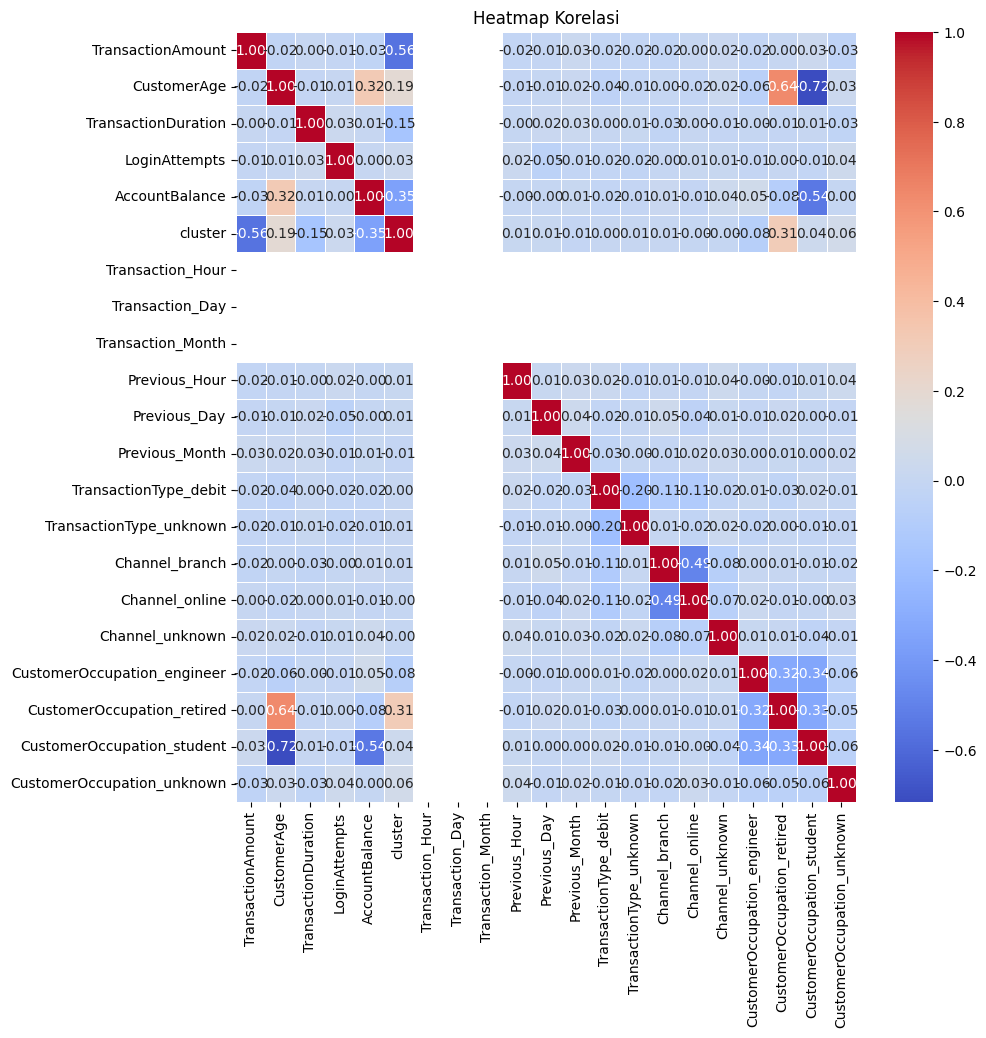

In [28]:
# plot matrik korelasi
num_features = df_model.select_dtypes(include=[np.number])
# Heatmap korelasi untuk fitur numerik
plt.figure(figsize=(10, 10))
correlation_matrix = num_features.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi')
plt.show()

## Tangani outlier

In [29]:
# cek outlier

numeric_columns = df_model.select_dtypes(include=['number']).columns

outlier_summary = []

for col in numeric_columns:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df_model[(df_model[col] < lower_bound) | (df_model[col] > upper_bound)]

    outlier_summary.append({
        'Feature': col,
        'Jumlah Outlier': len(outliers),
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df)

                        Feature  Jumlah Outlier  Lower Bound  Upper Bound
0             TransactionAmount             109   -406.07125    898.59875
1                   CustomerAge               0    -21.00000    107.00000
2           TransactionDuration               0    -84.00000    308.00000
3                 LoginAttempts             119      1.00000      1.00000
4                AccountBalance               0  -7666.56750  16829.23250
5                       cluster               0     -3.50000      8.50000
6              Transaction_Hour               0      8.00000      8.00000
7               Transaction_Day               0      4.00000      4.00000
8             Transaction_Month               0     11.00000     11.00000
9                 Previous_Hour               0     14.50000     18.50000
10                 Previous_Day               0    -14.50000     45.50000
11               Previous_Month               0     -7.50000     20.50000
12        TransactionType_debit       

**Insight**

Berdasarkan deteksi outlier menggunakan metode IQR, analisis difokuskan pada fitur numerik kontinu seperti TransactionAmount dan LoginAttempts. Fitur hasil encoding kategorikal tidak dianalisis sebagai outlier karena bersifat biner. Ditemukan bahwa TransactionAmount memiliki jumlah outlier yang signifikan sehingga dilakukan teknik capping (winsorizing) untuk membatasi nilai ekstrem tanpa menghilangkan data. Sementara itu, fitur LoginAttempts memiliki variasi yang sangat rendah sehingga pengaruhnya terhadap model clustering relatif kecil.

In [30]:
# Tangani outlier
numeric_cols = ['TransactionAmount']

for col in numeric_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df_model.loc[:, col] = df_model[col].clip(lower, upper)

    print(f"{col} done | batas: ({lower:.2f}, {upper:.2f})")

TransactionAmount done | batas: (-406.07, 898.60)


In [31]:
# cek hasil
for col in numeric_cols:
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((df_model[col] < lower) | (df_model[col] > upper)).sum()
    print(f"{col}: {count} outlier tersisa")

TransactionAmount: 0 outlier tersisa


## Data normalisasi

In [32]:
from sklearn.preprocessing import MinMaxScaler

# Buat instance scaler
scaler = MinMaxScaler()

# Ambil kolom numerik kecuali cluster
numeric_cols = df_model.select_dtypes(
    include=['int64', 'float64']
).columns.drop('cluster')

# Normalisasi hanya feature
df_model[numeric_cols] = scaler.fit_transform(
    df_model[numeric_cols]
)

# Cek hasil
df_model.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance,cluster,Transaction_Hour,Transaction_Day,Transaction_Month,Previous_Hour,...,Previous_Month,TransactionType_debit,TransactionType_unknown,Channel_branch,Channel_online,Channel_unknown,CustomerOccupation_engineer,CustomerOccupation_retired,CustomerOccupation_student,CustomerOccupation_unknown
count,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.0,2486.0,2486.0,2486.000000,...,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000,2486.000000
mean,0.315192,0.429554,0.377219,0.030471,0.336786,2.260257,8.0,4.0,11.0,16.625101,...,6.565165,0.763073,0.012068,0.341915,0.318986,0.010861,0.248592,0.232904,0.258648,0.009252
std,0.277137,0.285906,0.239844,0.148777,0.260580,1.424225,0.0,0.0,0.0,0.731745,...,3.484195,0.425283,0.109210,0.474447,0.466178,0.103669,0.432284,0.422767,0.437980,0.095760
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.0,4.0,11.0,16.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.092304,0.145161,0.182759,0.000000,0.095324,1.000000,8.0,4.0,11.0,16.000000,...,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.235362,0.435484,0.351724,0.000000,0.311329,3.000000,8.0,4.0,11.0,16.000000,...,7.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.455382,0.661290,0.520690,0.000000,0.506970,4.000000,8.0,4.0,11.0,17.000000,...,10.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,4.000000,8.0,4.0,11.0,18.000000,...,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# **6. Data Splitting**

In [34]:
from sklearn.model_selection import train_test_split

# Feature dan target
X = df_model.drop('cluster', axis=1)
y = df_model['cluster']

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Cek ukuran data
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1988, 20)
X_test  : (498, 20)
y_train : (1988,)
y_test  : (498,)


# **7. Membangun Model Klasifikasi**


## Decesion Tree

In [97]:
# Model Decision Tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model Decision Tree
model = DecisionTreeClassifier(
    random_state=42
)

# Training
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9216867469879518

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.87      0.87        75
           1       0.91      0.97      0.94       101
           2       0.91      0.89      0.90        70
           3       0.93      0.93      0.93       122
           4       0.96      0.93      0.95       130

    accuracy                           0.92       498
   macro avg       0.92      0.92      0.92       498
weighted avg       0.92      0.92      0.92       498



**Kesimpulan**

Model Decision Tree berhasil melakukan klasifikasi cluster dengan performa yang sangat baik, ditunjukkan oleh accuracy sebesar 92.17% dan nilai precision, recall, serta f1-score yang mayoritas berada di atas 0.90. Cluster 4 menjadi cluster yang paling mudah dikenali oleh model, sedangkan cluster 0 memiliki performa paling rendah namun tetap berada pada kategori baik. Secara keseluruhan, model mampu mempelajari pola hasil clustering secara efektif dan dapat digunakan untuk memprediksi kategori cluster pada data baru.

## SVC

In [98]:
# Model SVC
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Model SVC
model = SVC(
    kernel='rbf',
    random_state=42
)

# Training
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.46987951807228917

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        75
           1       0.00      0.00      0.00       101
           2       0.00      0.00      0.00        70
           3       0.71      0.85      0.78       122
           4       0.37      1.00      0.54       130

    accuracy                           0.47       498
   macro avg       0.22      0.37      0.26       498
weighted avg       0.27      0.47      0.33       498



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Kesimpulan**

Model SVC menghasilkan performa yang kurang optimal dengan accuracy sebesar 46.99%. Model hanya mampu mengenali cluster tertentu, terutama cluster 3 dan 4, sedangkan cluster lainnya tidak dapat diprediksi dengan baik. Berdasarkan hasil tersebut, model Decision Tree lebih efektif digunakan pada dataset ini dibandingkan SVC karena mampu menghasilkan akurasi dan kestabilan klasifikasi yang jauh lebih baik.

## Random Forest

In [99]:
# Model Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Model Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Training
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Evaluasi
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9417670682730924

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.93      0.93        75
           1       0.93      0.98      0.96       101
           2       0.94      0.93      0.94        70
           3       0.94      0.95      0.95       122
           4       0.95      0.92      0.93       130

    accuracy                           0.94       498
   macro avg       0.94      0.94      0.94       498
weighted avg       0.94      0.94      0.94       498



**Kesimpulan**

Model Random Forest merupakan model terbaik pada penelitian ini karena menghasilkan accuracy tertinggi sebesar 94.18% serta nilai precision, recall, dan f1-score yang stabil pada seluruh cluster. Model mampu mempelajari pola data transaksi pelanggan dengan sangat baik dan memberikan performa klasifikasi yang lebih optimal dibandingkan Decision Tree maupun SVC.

# **8. Kesimpulan**

## **Kesimpulan**

Berdasarkan hasil penelitian yang telah dilakukan, metode clustering berhasil digunakan untuk mengelompokkan data transaksi pelanggan berdasarkan karakteristik transaksi, saldo akun, usia pelanggan, durasi transaksi, dan aktivitas login. Hasil clustering menghasilkan lima kelompok pelanggan dengan karakteristik yang berbeda-beda sehingga dapat memberikan informasi yang lebih jelas mengenai pola perilaku transaksi pelanggan.

Selanjutnya, hasil clustering digunakan sebagai label pada proses klasifikasi menggunakan beberapa model machine learning, yaitu Decision Tree, Support Vector Machine (SVC), dan Random Forest. Berdasarkan hasil evaluasi, model Random Forest menghasilkan performa terbaik dengan accuracy sebesar 94.18%, diikuti Decision Tree sebesar 92.17%, sedangkan SVC menghasilkan accuracy sebesar 46.99%.

Model Random Forest menunjukkan performa yang paling stabil dengan nilai precision, recall, dan f1-score yang tinggi pada seluruh cluster. Hal tersebut menunjukkan bahwa Random Forest mampu mempelajari pola data transaksi dengan sangat baik serta memiliki kemampuan klasifikasi yang lebih optimal dibandingkan model lainnya.

Selain itu, proses preprocessing data seperti konversi datetime, encoding data kategorikal, dan normalisasi fitur numerik memberikan pengaruh penting terhadap performa model. Tahapan preprocessing berhasil membantu model dalam mengenali pola data secara lebih efektif.

Berdasarkan hasil penelitian, dapat disimpulkan bahwa kombinasi metode clustering dan klasifikasi machine learning mampu digunakan untuk menganalisis pola transaksi pelanggan dengan baik. Model Random Forest menjadi model terbaik pada penelitian ini karena menghasilkan tingkat akurasi dan kestabilan performa yang paling tinggi dibandingkan model lainnya.
